# Diamonds Dataset EDA

This notebook performs an Exploratory Data Analysis (EDA) on the `diamonds.csv` dataset. 

The goal is to:
1. Clean the data.
2. Handle outliers.
3. Analyze correlations.
4. Identify the top drivers of price.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Setting plot style
sns.set_theme(style="whitegrid")

## 1. Data Loading and Cleaning

In [2]:
# Load the dataset
df = pd.read_csv('diamonds.csv')

# Remove the redundant index column if it exists
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)
elif df.columns[0] == '':
    df.drop(columns=[df.columns[0]], inplace=True)

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (53940, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [3]:
# Check for missing values
print("Missing values:\n", df.isnull().sum())

Missing values:
 carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64


## 2. Handling Outliers

Diamonds cannot have 0 width, length, or depth. We'll check for these and treat them as outliers/errors.

In [4]:
# Check for zero values in dimensions
print("Zero values in dimensions:")
print((df[['x', 'y', 'z']] == 0).sum())

# Drop rows with zero dimensions
df = df[(df[['x', 'y', 'z']] != 0).all(axis=1)]

# Detect outliers using IQR for continuous variables
def handle_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]

# We'll apply outlier filtering selectively as some 'outliers' might be real (very large diamonds)
print(f"Shape after dropping zero dimensions: {df.shape}")

Zero values in dimensions:
x     8
y     7
z    20
dtype: int64
Shape after dropping zero dimensions: (53920, 10)


## 3. Correlation Analysis

To generate a correlation heatmap, we need to convert categorical variables (`cut`, `color`, `clarity`) to numerical values. These are ordinal categories, so we'll map them accordingly.

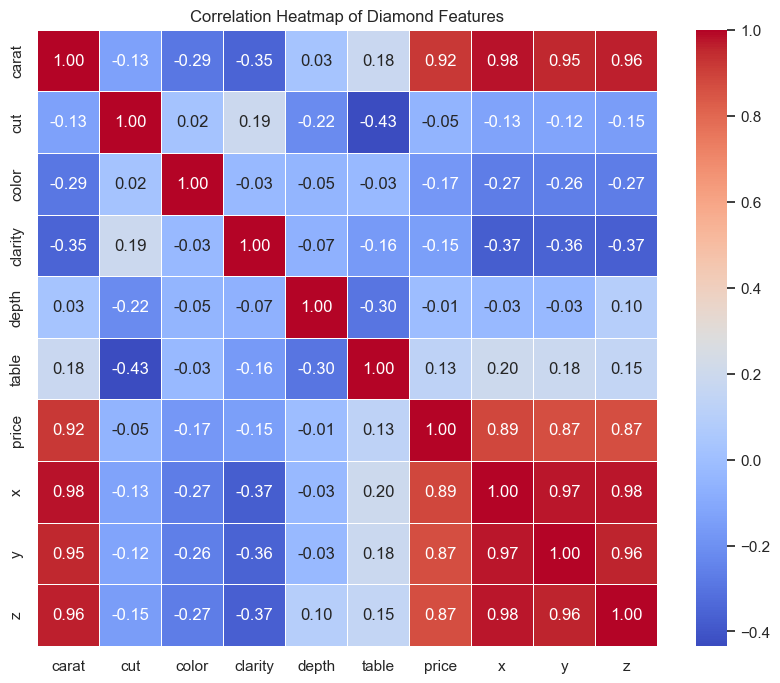

In [5]:
# Encode ordinal categorical variables
cut_map = {"Fair": 1, "Good": 2, "Very Good": 3, "Premium": 4, "Ideal": 5}
color_map = {"J": 1, "I": 2, "H": 3, "G": 4, "F": 5, "E": 6, "D": 7}
clarity_map = {"I1": 1, "SI2": 2, "SI1": 3, "VS2": 4, "VS1": 5, "VVS2": 6, "VVS1": 7, "IF": 8}

df_encoded = df.copy()
df_encoded['cut'] = df_encoded['cut'].map(cut_map)
df_encoded['color'] = df_encoded['color'].map(color_map)
df_encoded['clarity'] = df_encoded['clarity'].map(clarity_map)

# Compute correlation matrix
corr = df_encoded.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Diamond Features')
plt.show()

## 4. Top 3 Drivers of Price

Based on the correlation matrix above, here are the top 3 drivers of price:

In [6]:
# Get correlations with price
price_corr = corr['price'].sort_values(ascending=False)
print("Correlations with Price:")
print(price_corr)

Correlations with Price:
price      1.000000
carat      0.921592
x          0.887231
z          0.868206
y          0.867864
table      0.127245
depth     -0.010729
cut       -0.053491
clarity   -0.146789
color     -0.172431
Name: price, dtype: float64


### Summary: Top 3 Drivers of Price

1. **Carat Weight (~0.92)**: This is by far the strongest driver of price. As the weight of the diamond increases, the price increases significantly.
2. **Dimensions (x, y, z) (~0.88)**: The physical dimensions (length, width, depth) are extremely highly correlated with price, as they are the primary physical attributes that determine a diamond's size and carat weight.
3. **Clarity (~0.15) / Color (~0.17)**: While important for quality, these categorical traits have a much smaller linear correlation with price compared to the physical size of the stone in this dataset.